In [ ]:
# Load dataframe

import pandas as pd
import matplotlib.pyplot as plt

df_public = pd.read_csv('healthy-food-survey-public.csv')
df_public

,food,yes,no,no_opinion
0,almonds,913,55,24
1,apples,945,31,7
2,avocados,882,88,59
3,baked potatoes,666,248,26
4,butter,338,600,34
5,canned tuna,704,243,62
6,carrots,935,44,16
7,cashews,826,133,35
8,cheddar cheese,531,362,60
9,chicken,883,73,14


In [ ]:
# Calculate the percentage of 'yes in the dataframe

df_public['public'] = df_public.eval('yes / (yes + no + no_opinion)')
df_public['public'] = df_public.eval('public * 100').round()
df_public

,food,yes,no,no_opinion,public
0,almonds,913,55,24,92.0
1,apples,945,31,7,96.0
2,avocados,882,88,59,86.0
3,baked potatoes,666,248,26,71.0
4,butter,338,600,34,35.0
5,canned tuna,704,243,62,70.0
6,carrots,935,44,16,94.0
7,cashews,826,133,35,83.0
8,cheddar cheese,531,362,60,56.0
9,chicken,883,73,14,91.0


In [ ]:
# Select the needed columns using pandas notion df[['col1', 'col2']] - This selects the columns in the inner brackets (Python List)

df_public = df_public[['food', 'public']]
df_public

,food,public
0,almonds,92.0
1,apples,96.0
2,avocados,86.0
3,baked potatoes,71.0
4,butter,35.0
5,canned tuna,70.0
6,carrots,94.0
7,cashews,83.0
8,cheddar cheese,56.0
9,chicken,91.0


In [7]:
# Load dataframe

df_experts = pd.read_csv('healthy-food-survey-experts.csv')
df_experts

,food,yes,no,no_opinion
0,almonds,312,6,2
1,apples,313,1,3
2,avocados,308,9,6
3,baked potatoes,226,69,19
4,butter,131,158,42
5,canned tuna,279,37,18
6,carrots,324,2,2
7,cashews,270,21,8
8,cheddar cheese,197,116,32
9,chicken,282,11,17


In [8]:
# Calculate the percentage of 'yes in the dataframe 2

df_experts['experts'] = df_experts.eval('yes / (yes + no + no_opinion)')
df_experts['experts'] = df_experts.eval('experts * 100').round()
df_experts

,food,yes,no,no_opinion,experts
0,almonds,312,6,2,98.0
1,apples,313,1,3,99.0
2,avocados,308,9,6,95.0
3,baked potatoes,226,69,19,72.0
4,butter,131,158,42,40.0
5,canned tuna,279,37,18,84.0
6,carrots,324,2,2,99.0
7,cashews,270,21,8,90.0
8,cheddar cheese,197,116,32,57.0
9,chicken,282,11,17,91.0


In [10]:
# Select the needed columns using pandas notion df[['col1', 'col2']] - This selects the columns in the inner brackets (Python List) 2

df_experts = df_experts[['food', 'experts']]
df_experts

,food,experts
0,almonds,98.0
1,apples,99.0
2,avocados,95.0
3,baked potatoes,72.0
4,butter,40.0
5,canned tuna,84.0
6,carrots,99.0
7,cashews,90.0
8,cheddar cheese,57.0
9,chicken,91.0


In [12]:
# Merge the datasets

df = df_public.merge(df_experts, on='food', how='left')
df

,food,public,experts
0,almonds,92.0,98.0
1,apples,96.0,99.0
2,avocados,86.0,95.0
3,baked potatoes,71.0,72.0
4,butter,35.0,40.0
5,canned tuna,70.0,84.0
6,carrots,94.0,99.0
7,cashews,83.0,90.0
8,cheddar cheese,56.0,57.0
9,chicken,91.0,91.0


Text(0.5, 1.0, 'Is Food Heaithy?')

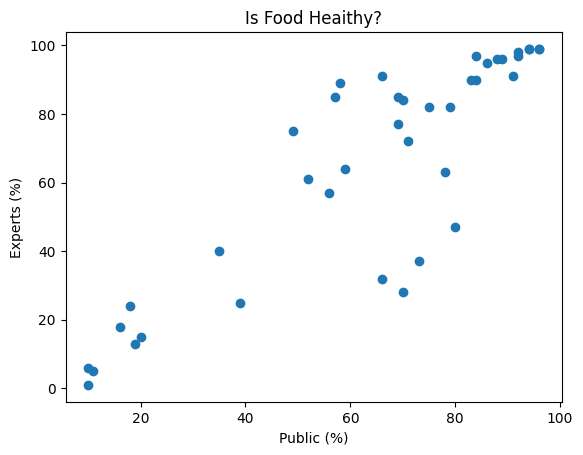

In [13]:
# Visualizing paired data

plt.scatter(df['public'], df['experts'])
plt.xlabel('Public (%)')
plt.ylabel('Experts (%)')
plt.title('Is Food Heaithy?')

In [27]:
# Define format_plot()

def format_plot():
    plt.xlabel('Public (%)')
    plt.ylabel('Experts (%)')
    plt.title('Is Food Heaithy?')

In [ ]:
# Define add_equality_line()
# Pro tip 1: Add an equality line
# Code for quality line

def add_equality_line():
    x = [0, 50, 100]
    y = [0, 50, 100]
    plt.plot(x, y, color='black', alpha=0.5, linestyle='--')

In [ ]:
# Define square_the_plot()
# Pro tip 2: Square up the plot

def square_the_plot():
    plt.xlim(0, 100)
    plt.ylim(0, 100)
    ax = plt.gca()
    ax.set_aspect(1)

In [20]:
# Pro tip 3: Change marker transparency

def plot_data():
    plt.scatter(df['public'], df['experts'], alpha=0.5)

In [ ]:
# Calculate the difference between public and experts to get the highest disagreement & limiting to top 4

df['public_minus_experts'] = df.eval('public - experts')
df = df.sort_values(by='public_minus_experts', ascending=False)
highest_disagreement = df.head(4)
highest_disagreement

,food,public,experts,public_minus_experts
19,granola bar,70.0,28.0,42.0
11,coconut oil,73.0,37.0,36.0
17,frozen yogurt,66.0,32.0,34.0
18,granola,80.0,47.0,33.0


In [26]:
# Defining add_labels

def add_labels(df, x_col, y_col, label_col):
    for (i, row) in df.iterrows():
        x = row[x_col]
        y = row[y_col]
        offset_spacing = ' '
        label = offset_spacing + row[label_col]
        plt.text(x, y, label, va='center', ha='left')

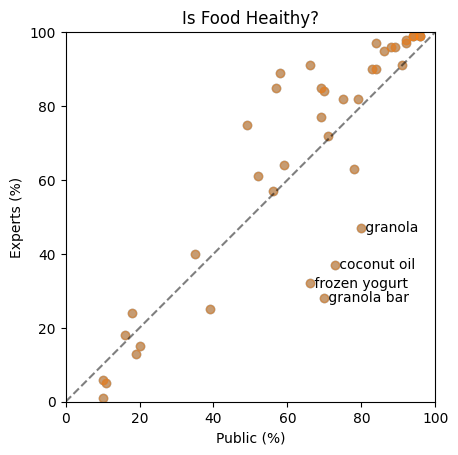

In [28]:
# Storytelling: labeling outliers

plt.scatter(df['public'], df['experts'], alpha=0.5)
format_plot()
plot_data()
add_equality_line()
square_the_plot()
add_labels(highest_disagreement, 'public', 'experts', 'food')

In [ ]:
# FULL CODE FOR PAIRED DATA SCATTERED PLOT

def format_plot():
    plt.xlabel('Public (%)')
    plt.ylabel('Experts (%)')
    plt.title('Is food healthy?')
    
def add_equality_line():
    x = [0, 50, 100]
    y = [0, 50, 100]
    plt.plot(x, y, color='black', alpha=0.5, linestyle='--')

def square_the_plot():
    plt.xlim(0, 100)
    plt.ylim(0, 100)
    ax = plt.gca()
    ax.set_aspect(1)

def add_labels(df, x_col, y_col, label_col):
    for (i, row) in df.iterrows():
        x = row[x_col]
        y = row[y_col]
        offset_spacing = "  "
        label = offset_spacing + row[label_col]
        plt.text(x, y, label, va='center', ha='left')

plt.scatter(df['public'], df['experts'], alpha=0.5)
format_plot()
add_equality_line()
square_the_plot()
add_labels(highest_disagreement, 'public', 'experts', 'food')